# Introduction


## Setup


In [1]:
import sys
from pathlib import Path

for _p in (Path.cwd(), *Path.cwd().parents):
    if (_p / "src" / "rl_suite").is_dir():
        sys.path.insert(0, str(_p / "src"))
        break

%matplotlib inline

import gymnasium as gym

import rl_suite as rl

utils = rl.RLToolbox.utils


In [2]:
ENV_ID = "FrozenLake-v1"
GOAL_REWARD, HOLE_REWARD, OTHER_REWARD = 1000, -5, 0
IS_SLIPPERY = False
SEED = 10

env = gym.make(
    ENV_ID,
    map_name="4x4",
    is_slippery=IS_SLIPPERY,
    render_mode="rgb_array",
    reward_schedule=(GOAL_REWARD, HOLE_REWARD, OTHER_REWARD),
)

toolbox = rl.RLToolbox(env)
human_runner = toolbox.utils.human_agent
rl_runner = toolbox.utils.rl_agent
render_fn = utils.render_env_in_notebook


## Initial Analysis


## Main Loop

Here are the functions we will be using to execute the environment in a loop:

In [3]:
# Environment execution lives in rl_suite.RLToolbox.utils.HumanEnvironmentRunner and RLEnvironmentRunner.


## Human player

We can act as the agent by selecting actions and stepping the environment through time to see its responses to our actions:

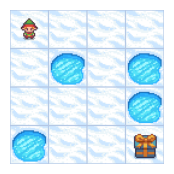

--> The result of taking action 1 is:
     S = 4
     R = 0
     p = 1.0


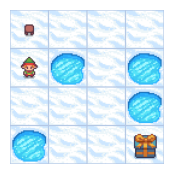

--> The result of taking action 1 is:
     S = 8
     R = 0
     p = 1.0


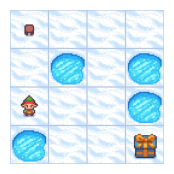

--> The result of taking action 2 is:
     S = 9
     R = 0
     p = 1.0


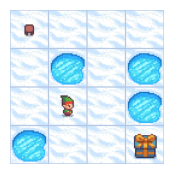

--> The result of taking action 1 is:
     S = 13
     R = 0
     p = 1.0


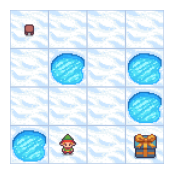

--> The result of taking action 2 is:
     S = 14
     R = 0
     p = 1.0


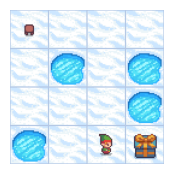

--> The result of taking action 2 is:
     S = 15
     R = 1000
     p = 1.0
Episode has terminated!
Final state of environment:
Yay! You reached the goal!


[(4, 1, 0), (8, 1, 0), (9, 2, 0), (13, 1, 0), (14, 2, 0), (15, 2, 1000)]

In [4]:
human_runner.run_episode(
    seed=SEED,
    render_fn=render_fn,
    render_each_step=True,
    print_messages=True,
    action_prompt=(
        "Possible actions: [0: left, 1: down, 2: right, 3: up], "
        "or 'exit' to stop program: "
    ),
    invalid_action_message=lambda user_input: (
        f"Invalid input: {user_input!r}. Please enter an integer action or 'exit'."
    ),
    step_message=lambda action, state, reward, info: (
        f"--> The result of taking action {action} is:\n"
        f"     S = {state}\n"
        f"     R = {reward}\n"
        f"     p = {info.get('prob', 'N/A')}"
    ),
    final_message=lambda state, terminated, truncated, exited: (
        (
            "Episode has been terminated by user."
            if exited
            else "Episode has terminated!"
            if terminated
            else "Episode has finished due to truncate flag."
            if truncated
            else "Episode stopped."
        )
        + "\nFinal state of environment:\n"
        + ("Yay! You reached the goal!" if state == 15 else "You did not reach the goal.")
    ),
)


# Practical

## Part 3:


In [5]:
# GPI implementations live in rl.algorithms(env).gpi.


In [6]:
# Stochastic policy evaluation is available as agent.gpi.stochastic.


In [7]:
agent = rl.algorithms(env)
stochastic_gpi_agent = agent.gpi.stochastic
stochastic_gpi_agent.get_env_info(env)
policy, values = stochastic_gpi_agent.policy_evaluation(print_num_iter=True)
print(
    "\n\nFinal policy (unchanged because this is prediction, not policy improvement):"
    f"\n{policy}\n\nFinal values:\n{values}"
)


theta=0.02 and gamma=0.9 ====> number of steps in evalution: 19


Final policy (unchanged because this is prediction, not policy improvement):
[[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]

Final values:
[np.float64(1.766129725980429), np.float64(0.9884768263807916), np.float64(7.2101028754900085), np.float64(1.0822430643601517), np.float64(3.38232744547069), 0, np.float64(22.77694898017344), 1, np.float64(15.45146742246838), np.float64(54.40025355508355), np.float64(104.13295170995085), 1, 1, np.float64(127.7521357412518), np.float64(390.1922258160387), 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,

## Part 4:

Policy Improvement:


In [8]:
agent = rl.algorithms(env)
deterministic_gpi_agent = agent.gpi.deterministic
deterministic_gpi_agent.get_env_info(env)
deterministic_gpi_agent.policy_iteration(print_num_iter=True)


theta=0.02 and gamma=0.9 ====> number of steps in evalution: 17
theta=0.02 and gamma=0.9 ====> number of steps in evalution: 2
theta=0.02 and gamma=0.9 ====> number of steps in evalution: 3
theta=0.02 and gamma=0.9 ====> number of steps in evalution: 2
theta=0.02 and gamma=0.9 ====> number of steps in evalution: 2
theta=0.02 and gamma=0.9 ====> number of steps in evalution: 2
theta=0.02 and gamma=0.9 ====> number of steps in evalution: 1
Number of iterations for policy iteration: 7


([591.021441,
  656.69049,
  729.6560999999999,
  656.69049,
  656.69049,
  0,
  810.7289999999999,
  1,
  729.6560999999999,
  810.7289999999999,
  900.81,
  1,
  1,
  900.81,
  1000.9,
  1,
  1,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  0,
  0,
  0,
  0],
 [1,
  2,
  1,
  0,
  1,
  np.int64(3),
  1,
  np.int64(1),
  2,
  1,
  1,
  np.int64(0),
  np.int64(0),
  2,
  2,
  np.int64(3)])

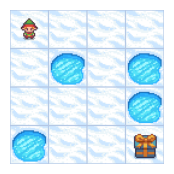

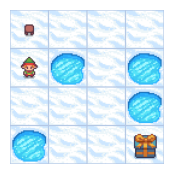

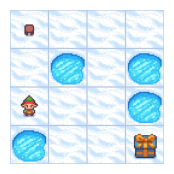

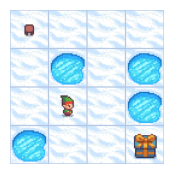

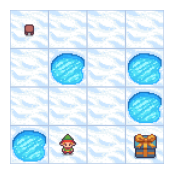

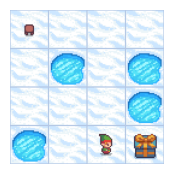

[(4, 1, 0), (8, 1, 0), (9, 2, 0), (13, 1, 0), (14, 2, 0), (15, 2, 1000)]

In [9]:
rl_runner.run_episode(
    agent=deterministic_gpi_agent,
    seed=SEED,
    render_fn=render_fn,
    render_each_step=True,
)


## Part 5:

Code the value iteration process

In [10]:
agent = rl.algorithms(env)
value_iter_agent = agent.gpi.value_iteration
value_iter_agent.get_env_info(env)
value_iter_agent.value_iteration(print_num_iter=True)


theta=0.02 and gamma=0.9 ====> number of steps in evalution: 7


Clearly value iteration takes far fewer iterations than policy iteration. Now we will test value iteration:

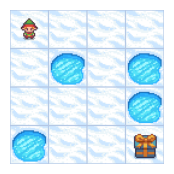

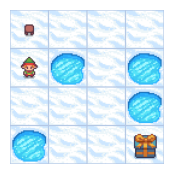

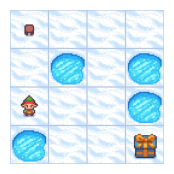

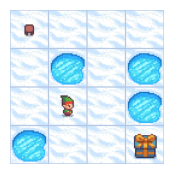

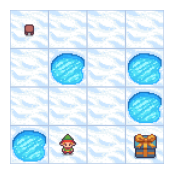

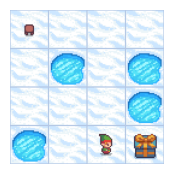

[(4, 1, 0), (8, 1, 0), (9, 2, 0), (13, 1, 0), (14, 2, 0), (15, 2, 1000)]

In [11]:
rl_runner.run_episode(
    agent=value_iter_agent,
    seed=SEED,
    render_fn=render_fn,
    render_each_step=True,
)


<!-- # Appendix A

Here is the full print of "env.unwrapped.P": -->